# Initialization of data and concatenating data as 1 dataframe

In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:


import pandas as pd

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
chronic_kidney_disease = fetch_ucirepo(id=336)

# data (as pandas dataframes)
x = chronic_kidney_disease.data.features
y = chronic_kidney_disease.data.targets

df = pd.concat([x, y], axis=1)


# Converting hemoglobin value from g/dl to g/l

In [4]:
df.hemo = df.hemo * 10 # converts g/dl -> g/l
df.hemo

0      154.0
1      113.0
2       96.0
3      112.0
4      116.0
       ...  
395    157.0
396    165.0
397    158.0
398    142.0
399    158.0
Name: hemo, Length: 400, dtype: float64

## Class handling

At first found ckd\t converted to ckd (assumably a tabulator in data).
Then changing ckd -> a as affected and c as control

In [5]:
## combine ckd/t with ckd assumable a tabulator in dataset

df["class"] = df["class"].replace({
    "ckd\t": "ckd"
})

## rename classes ckd -> affected and notckd -> control

df["class"] = df["class"].replace({
    "ckd": "a",
    "notckd": "c"
})

df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,a
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,a
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,a
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,a
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,c
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,c
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,c
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,c


# noteja mikä data on ylimäärästä
tiputa:
- rbc
- pc
- pcc
- ba
- sc
- htn
- dm
- cad
- appet
- pe
- ane

# data cleaning
Dropping unnecessary columns from dataset

In [6]:
df = df.drop(columns=["rbc", "pc", "pcc", "ba", "sc", "htn", "dm", "cad", "appet", "pe", "ane"])

df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,113.0,38.0,6000.0,NaN,a
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,96.0,31.0,7500.0,NaN,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


### Making sure all unnecessary data is dropped and no values changed

In [7]:
## making sure all unnecessary data is dropped and no values changed
print(df.columns)
df.shape

Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sod', 'pot', 'hemo', 'pcv',
       'wbcc', 'rbcc', 'class'],
      dtype='str')


(400, 14)

## Deleting lines with 3 or more NaN values
### Algorithm search down every row which include 3 or more NaN values and ignores class which is str

In [8]:
false_data_index_list = []

print("Length of the dataframe before dropped data: " + str(len(df)))

for index, row in df.iterrows():
    nan_rows_count = 0
    for column, value in row.items():
        if value == "a" or value == "c":
            continue
        if pd.isna(value):
            nan_rows_count += 1
            if nan_rows_count >=3:
                false_data_index_list.append(index)
                break


for i in false_data_index_list:
    df = df.drop(index=i)

print("New length of the dataframe with dropped data: " + str(len(df)))

Length of the dataframe before dropped data: 400
New length of the dataframe with dropped data: 265


### Splitting dataframe to 2 dataframes with affected and control groups

In [9]:
df_affected = df[(df["class"] == "a")]
df_control = df[(df["class"] == "c")]

print(f"Affected individuals: {len(df_affected)}")
print(f"Control individuals: {len(df_control)}")

print(f"Sum of affected and control: {len(df_affected)} + {len(df_control)} = {len(df_affected) + len(df_control)}")


Affected individuals: 126
Control individuals: 139
Sum of affected and control: 126 + 139 = 265


### replacing remaining NaNs with corresponding mean values

Rows with fewer than three missing values were retained. The remaining
missing numerical values were replaced with the mean of the corresponding
column within each group so that the observations could still be included
in the subsequent analysis.

In [10]:
numeric_columns = df.select_dtypes("float").columns
print("ennen: \n")
print("affected:")
print(df_affected.isna().sum())
print("")
print("control:")
print(df_control.isna().sum())

df_affected[numeric_columns] = df_affected[numeric_columns].fillna(
    df_affected[numeric_columns].mean()
)


df_control[numeric_columns] = df_control[numeric_columns].fillna(
    df_control[numeric_columns].mean()
)


print("\njälkeen:\n")
print("affected:")
print(df_affected.isna().sum())
print("")
print("control:")
print(df_control.isna().sum())

ennen: 

affected:
age       3
bp        1
sg        1
al        0
su        0
bgr       6
bu        1
sod      18
pot      18
hemo      1
pcv       1
wbcc     13
rbcc     18
class     0
dtype: int64

control:
age      0
bp       2
sg       0
al       0
su       0
bgr      4
bu       4
sod      3
pot      3
hemo     2
pcv      1
wbcc     3
rbcc     3
class    0
dtype: int64

jälkeen:

affected:
age      0
bp       0
sg       0
al       0
su       0
bgr      0
bu       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
class    0
dtype: int64

control:
age      0
bp       0
sg       0
al       0
su       0
bgr      0
bu       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
class    0
dtype: int64


In [11]:
df_affected.describe()

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,57.081301,80.720000,1.013560,1.849206,0.809524,181.200000,80.420000,133.731481,4.751852,106.432000,32.440000,9450.442478,3.976852
std,14.290469,15.706101,0.004508,1.437038,1.366539,91.276599,60.258855,7.093215,3.889174,21.808745,7.122247,3521.684231,0.781343
min,6.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,104.000000,2.500000,31.000000,9.000000,2600.000000,2.100000
25%,50.000000,70.000000,1.010000,0.250000,0.000000,108.250000,37.500000,132.000000,3.925000,95.250000,29.000000,7325.000000,3.500000
50%,60.000000,80.000000,1.015000,2.000000,0.000000,162.500000,60.000000,134.500000,4.400000,108.000000,32.720000,9450.442478,3.976852
75%,65.000000,90.000000,1.015000,3.000000,1.000000,238.750000,106.750000,138.000000,4.800000,120.000000,37.000000,10650.000000,4.300000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,322.000000,145.000000,47.000000,161.000000,52.000000,26400.000000,8.000000


In [12]:
df_affected

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,133.731481,4.751852,154.0,44.0,7800.000000,5.200000,a
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.000000,2.500000,112.0,32.0,6700.000000,3.900000,a
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,133.731481,4.751852,116.0,35.0,7300.000000,4.600000,a
5,60.0,90.0,1.015,3.0,0.0,74.0,25.0,142.000000,3.200000,122.0,39.0,7800.000000,4.400000,a
6,68.0,70.0,1.010,0.0,0.0,100.0,54.0,104.000000,4.000000,124.0,36.0,9450.442478,3.976852,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,62.0,90.0,1.020,2.0,1.0,169.0,48.0,138.000000,2.900000,134.0,47.0,11000.000000,6.100000,a
244,64.0,90.0,1.015,3.0,2.0,463.0,64.0,135.000000,4.100000,122.0,40.0,9800.000000,4.600000,a
246,48.0,110.0,1.015,3.0,0.0,106.0,215.0,120.000000,5.700000,86.0,26.0,5000.000000,2.500000,a
248,59.0,70.0,1.010,1.0,3.0,424.0,55.0,138.000000,4.500000,126.0,37.0,10200.000000,4.100000,a


In [13]:
df_control.describe()

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc
count,139.000000,139.000000,139.000000,139.0,139.0,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000
mean,46.568345,71.313869,1.022482,0.0,0.0,107.385185,32.874074,141.735294,4.335294,151.883212,46.246377,7708.088235,5.380882
std,15.903719,8.497017,0.002509,0.0,0.0,18.474026,11.314624,4.739956,0.589833,12.751849,4.092785,1795.326265,0.586505
min,12.000000,60.000000,1.020000,0.0,0.0,70.000000,10.000000,135.000000,3.300000,130.000000,40.000000,4300.000000,4.500000
25%,34.000000,60.000000,1.020000,0.0,0.0,93.500000,24.000000,138.000000,3.700000,141.000000,43.000000,6300.000000,4.900000
50%,46.000000,70.000000,1.020000,0.0,0.0,107.385185,32.874074,141.735294,4.500000,150.000000,46.000000,7500.000000,5.300000
75%,58.000000,80.000000,1.025000,0.0,0.0,123.000000,44.000000,145.500000,4.900000,161.500000,50.000000,9200.000000,5.900000
max,80.000000,80.000000,1.025000,0.0,0.0,140.000000,50.000000,150.000000,5.000000,178.000000,54.000000,11000.000000,6.500000


In [14]:
df_control

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
250,40.0,80.0,1.025,0.0,0.0,140.0,10.0,135.0,5.0,150.0,48.0,10400.0,4.5,c
251,23.0,80.0,1.025,0.0,0.0,70.0,36.0,150.0,4.6,170.0,52.0,9800.0,5.0,c
252,45.0,80.0,1.025,0.0,0.0,82.0,49.0,147.0,4.4,159.0,46.0,9100.0,4.7,c
253,57.0,80.0,1.025,0.0,0.0,119.0,17.0,135.0,4.7,154.0,42.0,6200.0,6.2,c
254,51.0,60.0,1.025,0.0,0.0,99.0,38.0,135.0,3.7,130.0,49.0,8300.0,5.2,c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,150.0,4.9,157.0,47.0,6700.0,4.9,c
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,141.0,3.5,165.0,54.0,7800.0,6.2,c
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,137.0,4.4,158.0,49.0,6600.0,5.4,c
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,135.0,4.9,142.0,51.0,7200.0,5.9,c


#### making sure that filtering was correct

In [15]:
if (len(df) - len(df_affected) - len(df_control)) == 0:
    print("Filtering was made correctly")
else:
    print("Filtering was not made correctly")

Filtering was made correctly


## Calculation of basic statistics
- Mean: The standard average. Add all numbers, then divide by how many numbers exist.
- Median (50%): The exact middle number when you line values up from low to high.
- Min value
- Max value
- Standard Deviation (std): The square root of variance. It shows standard distance from the average
- Unique
- Bottom 25 percentile
- Top 25 percentile

In [16]:
df_affected.describe(include="all")

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126
mean,57.081301,80.720000,1.013560,1.849206,0.809524,181.200000,80.420000,133.731481,4.751852,106.432000,32.440000,9450.442478,3.976852,NaN
std,14.290469,15.706101,0.004508,1.437038,1.366539,91.276599,60.258855,7.093215,3.889174,21.808745,7.122247,3521.684231,0.781343,NaN
min,6.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,104.000000,2.500000,31.000000,9.000000,2600.000000,2.100000,NaN
25%,50.000000,70.000000,1.010000,0.250000,0.000000,108.250000,37.500000,132.000000,3.925000,95.250000,29.000000,7325.000000,3.500000,NaN
50%,60.000000,80.000000,1.015000,2.000000,0.000000,162.500000,60.000000,134.500000,4.400000,108.000000,32.720000,9450.442478,3.976852,NaN
75%,65.000000,90.000000,1.015000,3.000000,1.000000,238.750000,106.750000,138.000000,4.800000,120.000000,37.000000,10650.000000,4.300000,NaN


In [17]:
df_control.describe(include="all")

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
count,139.000000,139.000000,139.000000,139.0,139.0,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,139
mean,46.568345,71.313869,1.022482,0.0,0.0,107.385185,32.874074,141.735294,4.335294,151.883212,46.246377,7708.088235,5.380882,NaN
std,15.903719,8.497017,0.002509,0.0,0.0,18.474026,11.314624,4.739956,0.589833,12.751849,4.092785,1795.326265,0.586505,NaN
min,12.000000,60.000000,1.020000,0.0,0.0,70.000000,10.000000,135.000000,3.300000,130.000000,40.000000,4300.000000,4.500000,NaN
25%,34.000000,60.000000,1.020000,0.0,0.0,93.500000,24.000000,138.000000,3.700000,141.000000,43.000000,6300.000000,4.900000,NaN
50%,46.000000,70.000000,1.020000,0.0,0.0,107.385185,32.874074,141.735294,4.500000,150.000000,46.000000,7500.000000,5.300000,NaN
75%,58.000000,80.000000,1.025000,0.0,0.0,123.000000,44.000000,145.500000,4.900000,161.500000,50.000000,9200.000000,5.900000,NaN


### Starting with affected

In [18]:
import matplotlib.pyplot as plt

def plot_data(df):
    plt.figure(figsize=(20, 15))
    for i, col in enumerate(df.select_dtypes(include=['int', 'float'])):
        plt.subplot(5, 3, i + 1)
        df[col].plot(kind='hist', title=col)
        plt.xlabel(col)

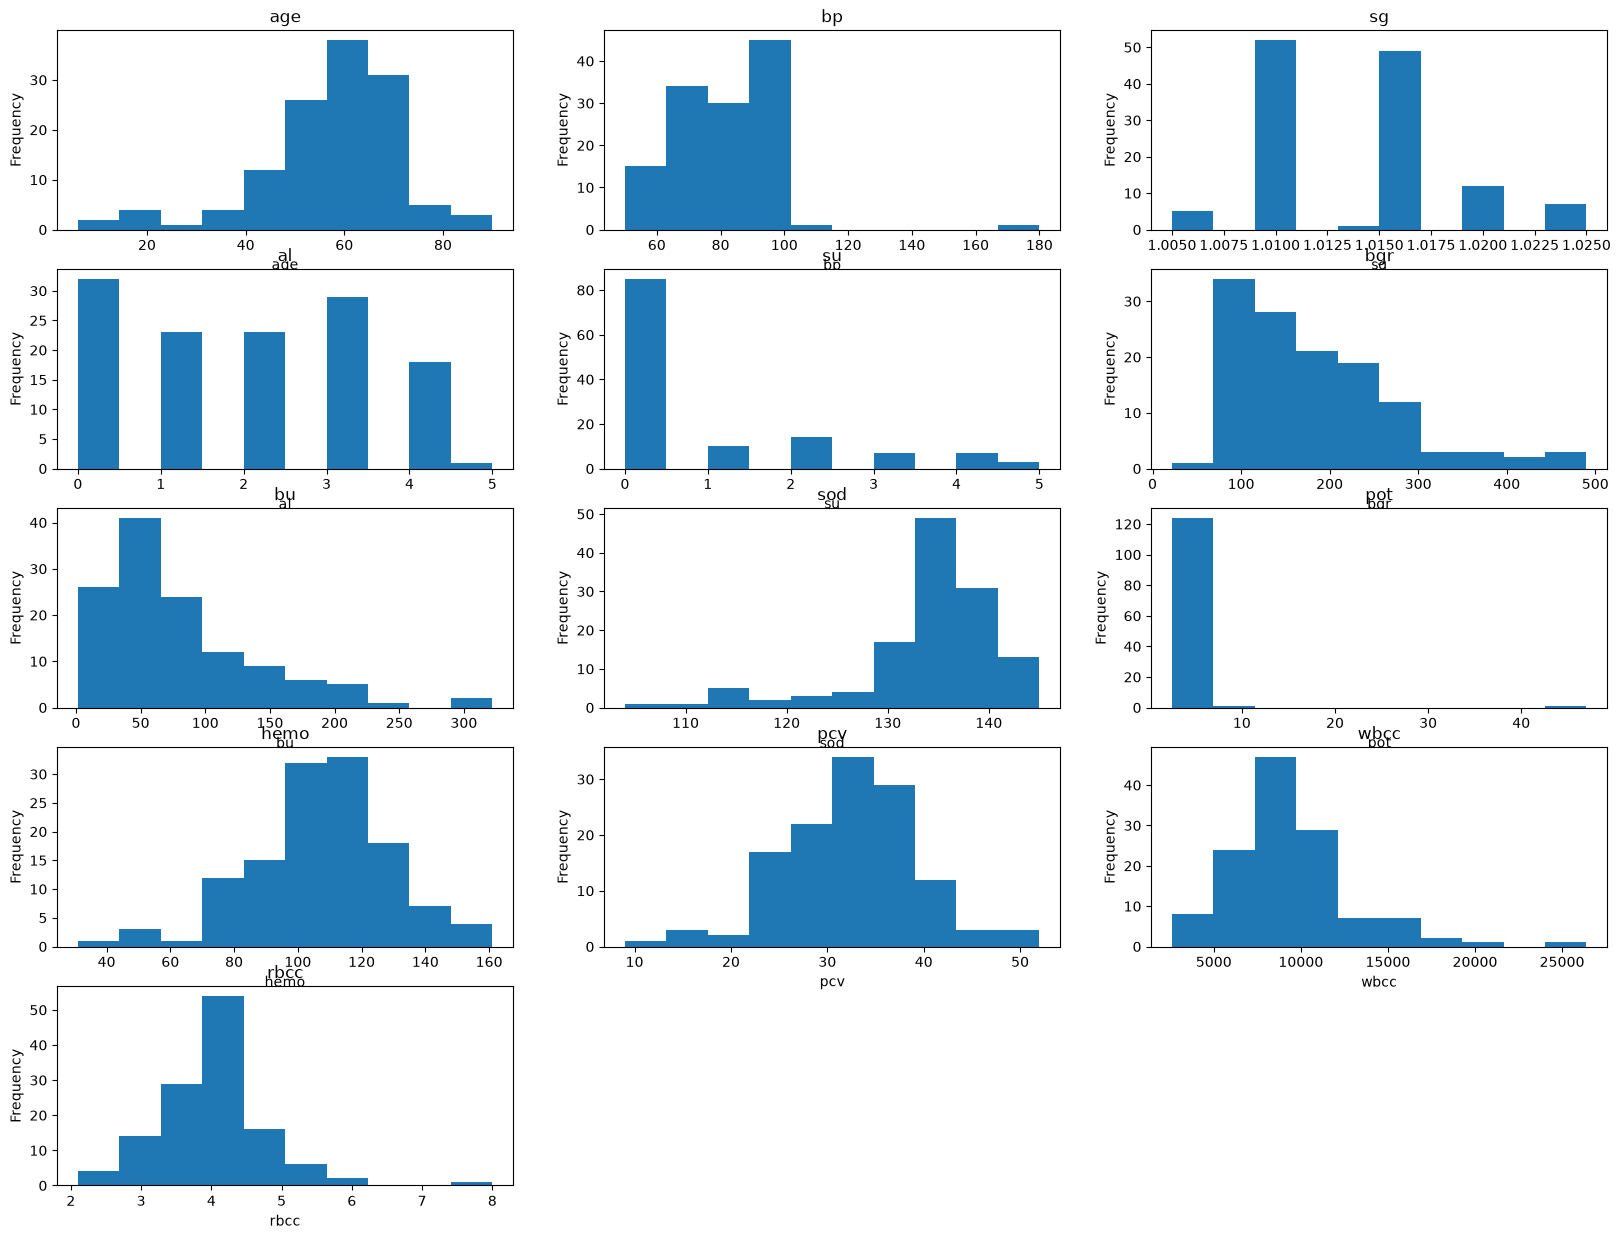

In [19]:
plot_data(df_affected)

## And control

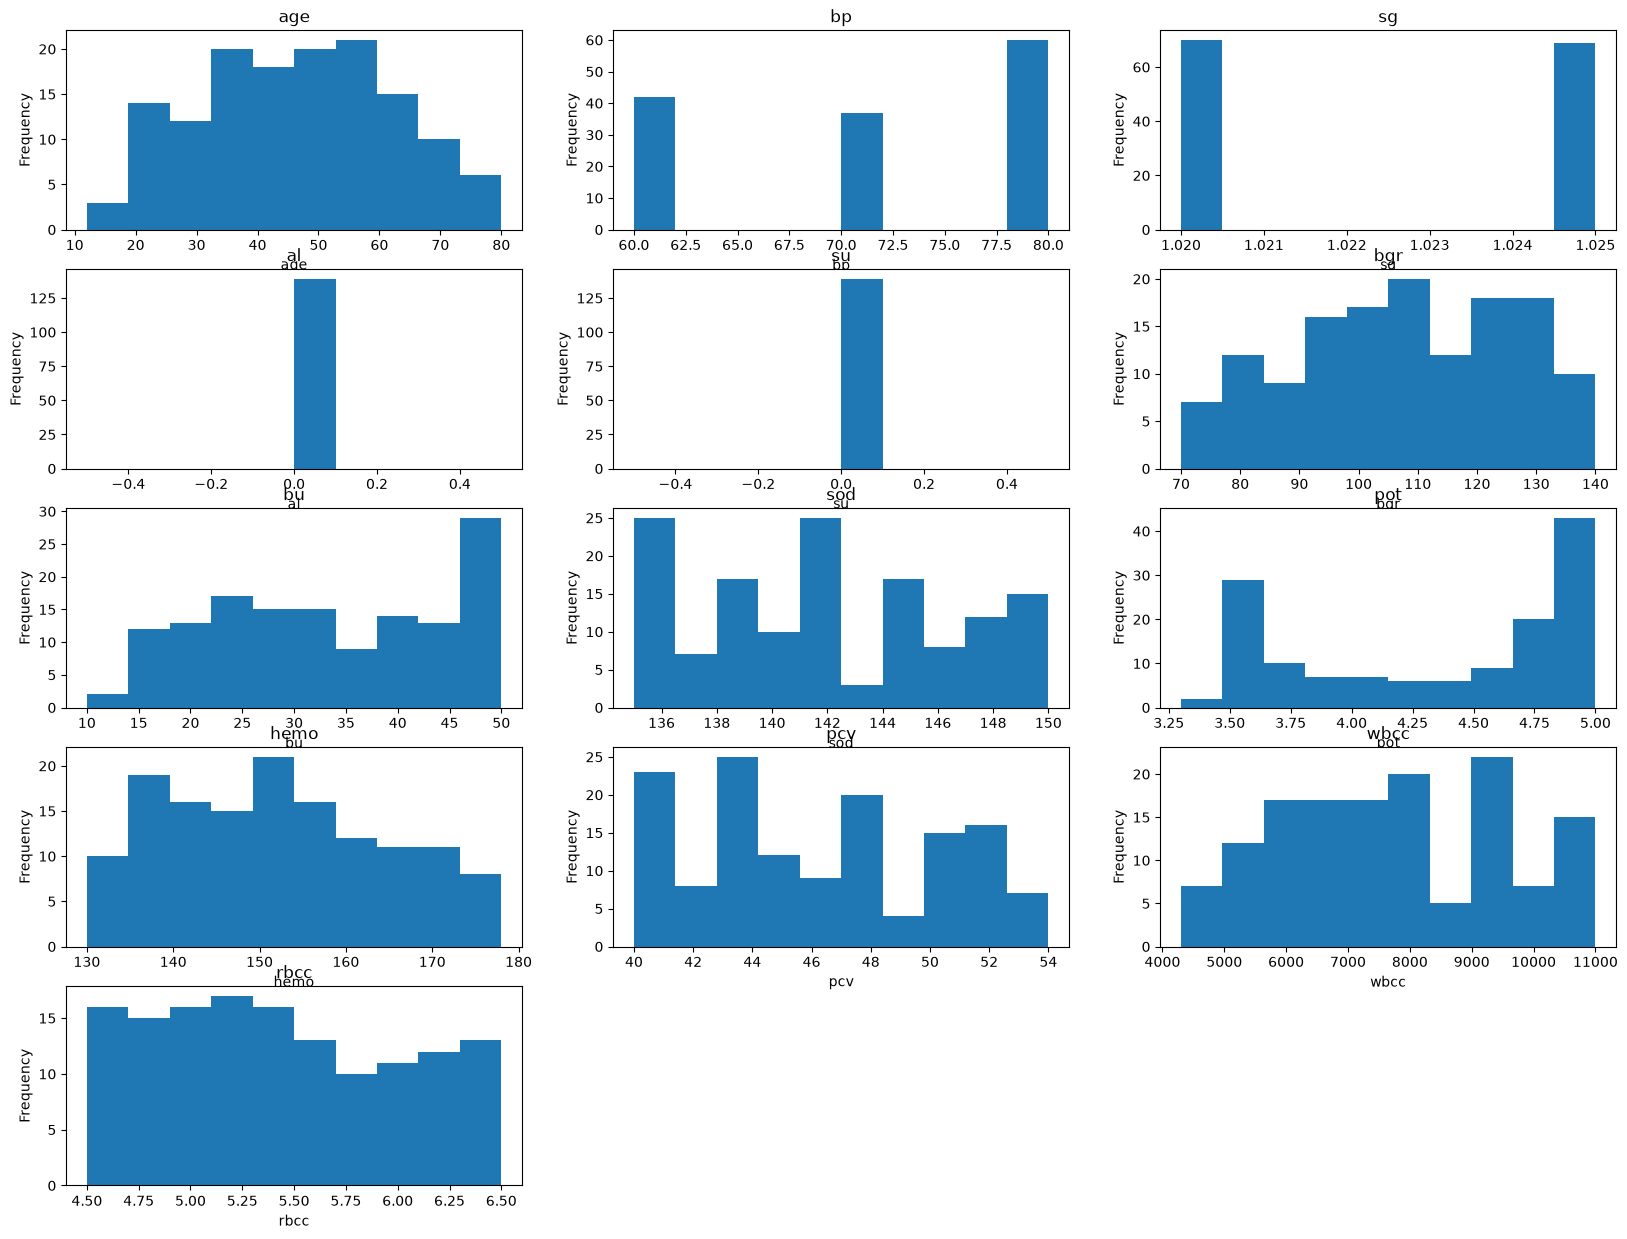

In [20]:
plot_data(df_control)

## Histogram interpretation:
### Values that had outliers and how we handled them
- bloodpressure (assyming it to be diastolic not systolic) with mean value
- potassium with mean value
- white bloodcell count with mean value

In [21]:
df_affected['bp'] = df_affected['bp'].apply(lambda x: df_affected['bp'].mean() if x > 120 else x)

df_affected['pot'] = df_affected['pot'].apply(lambda x: df_affected['pot'].mean() if x > 20 else x)

df_affected['wbcc'] = df_affected['wbcc'].apply(lambda x: df_affected['wbcc'].mean() if x > 26000 else x)

df_control['bp'] = df_control['bp'].apply(lambda x: df_control['bp'].mean() if x > 120 else x)

df_control['pot'] = df_control['pot'].apply(lambda x: df_control['pot'].mean() if x > 20 else x)

df_control['wbcc'] = df_control['wbcc'].apply(lambda x: df_control['wbcc'].mean() if x > 26000 else x)

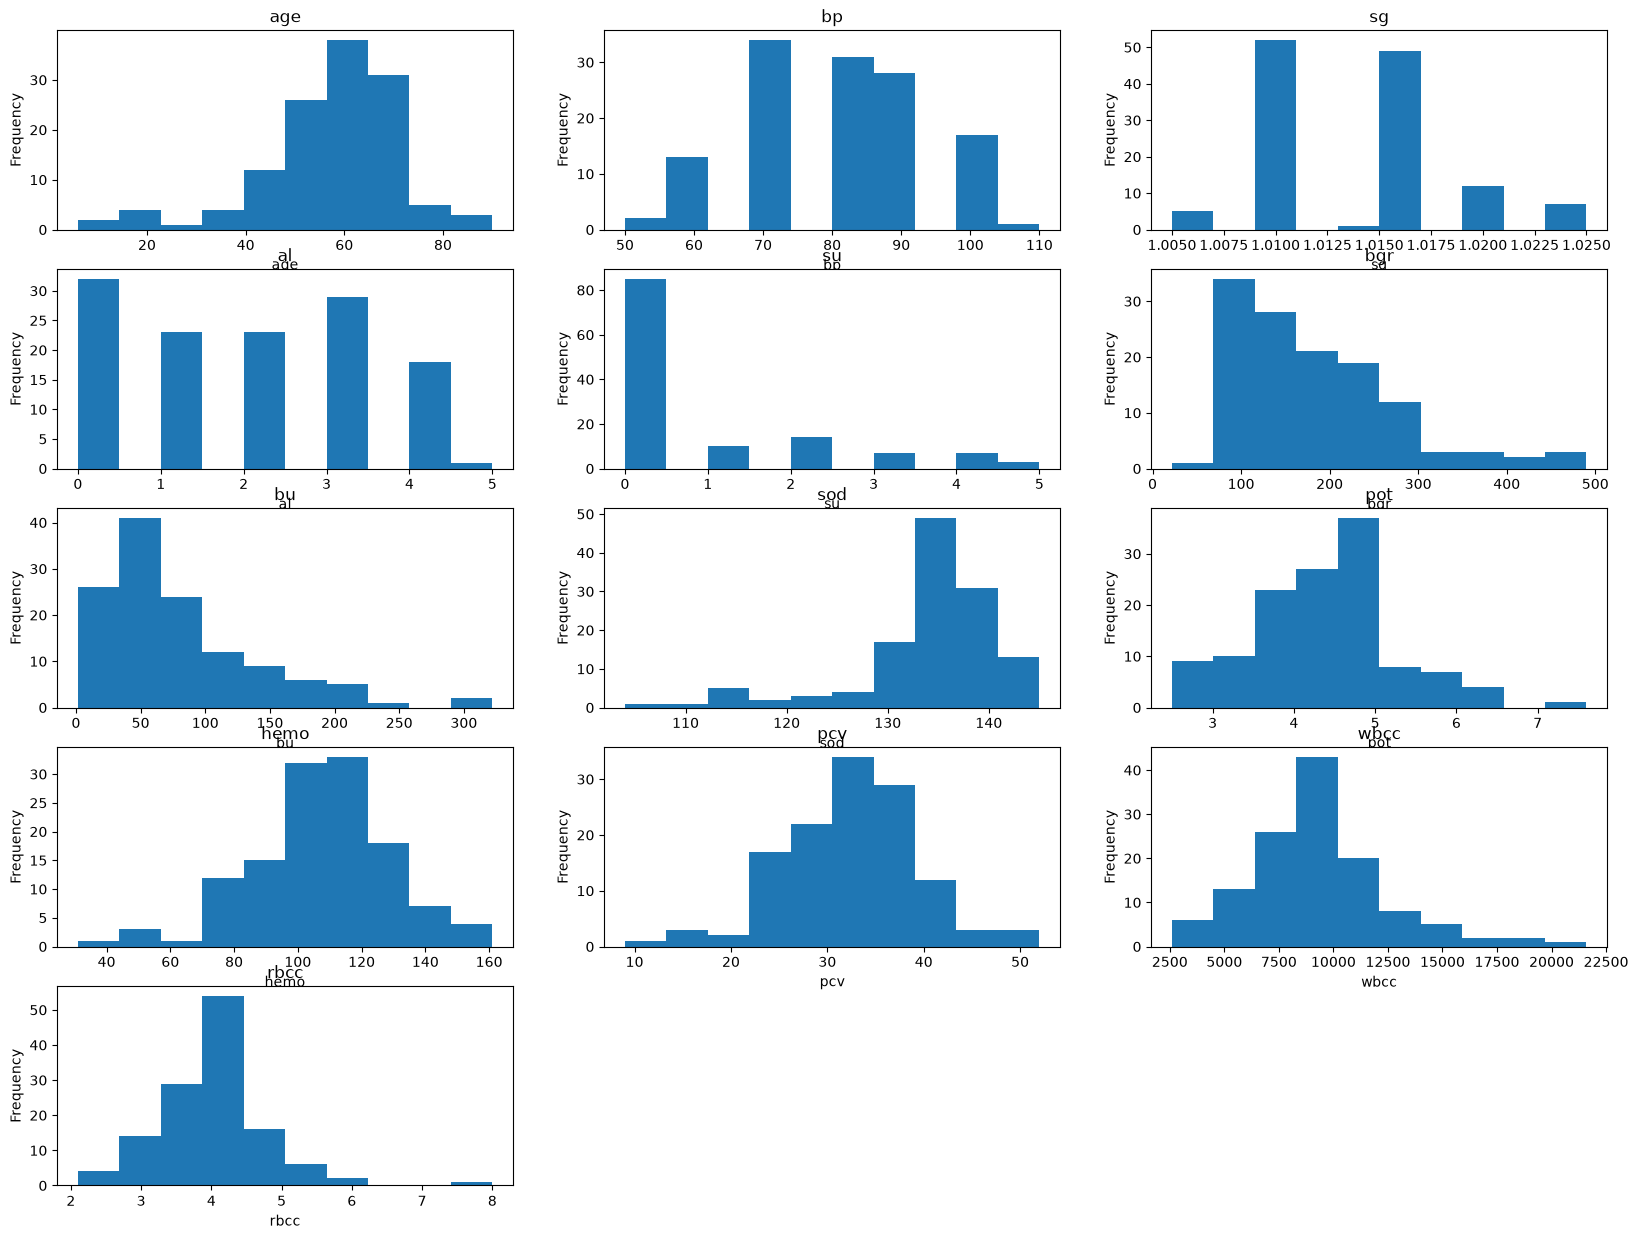

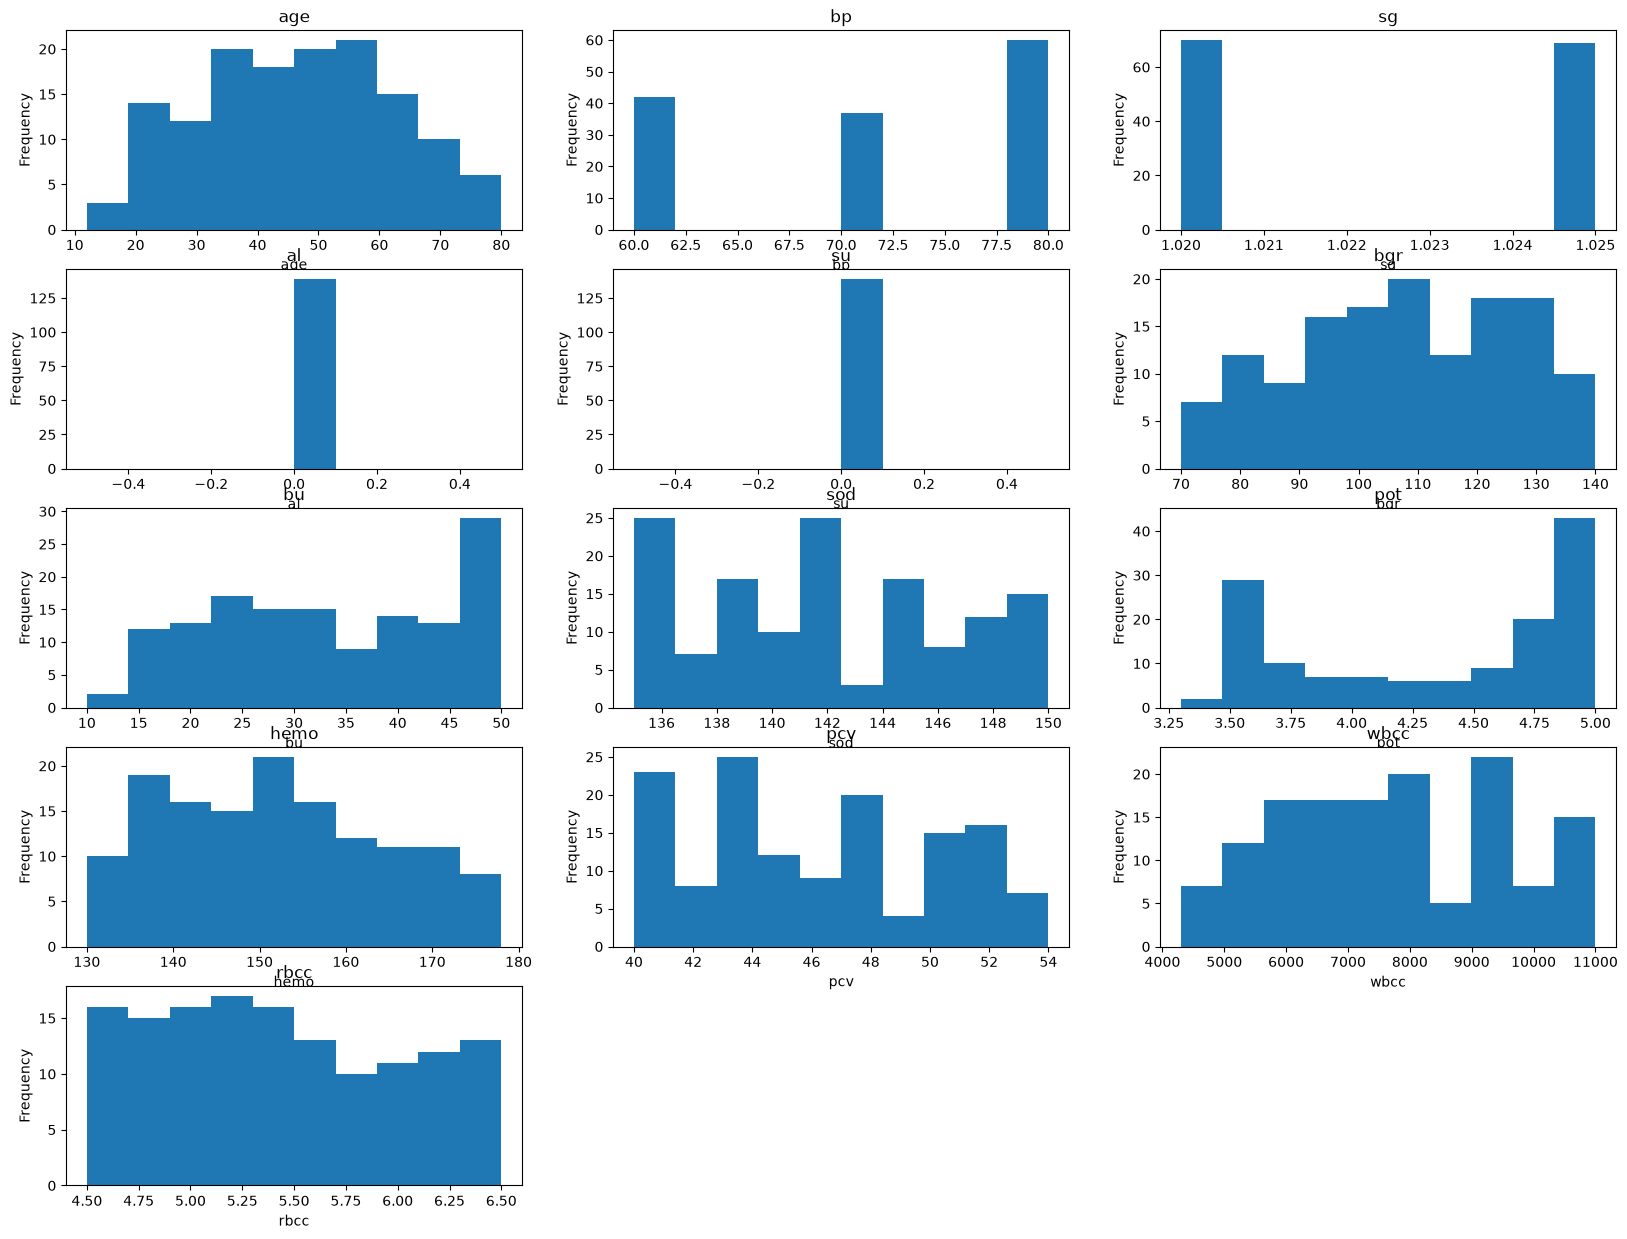

In [22]:
plot_data(df_affected)
plot_data(df_control)

In [23]:
corr_affected = df_affected.drop(columns=["class"]).corr()
corr_control = df_control.drop(columns=["class"]).corr()

In [24]:
corr_affected

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc
age,1.000000,0.076154,-0.004819,-0.016571,0.138345,0.198776,0.022488,-0.032251,0.107531,-0.005994,-0.043052,0.011189,-0.014509
bp,0.076154,1.000000,0.066779,0.105836,0.076879,-0.029228,0.135540,0.127177,0.117920,-0.130731,-0.120194,-0.137133,0.089747
sg,-0.004819,0.066779,1.000000,-0.061097,-0.043993,-0.080525,-0.037699,0.135620,0.073917,0.113712,0.106540,-0.089232,0.114892
al,-0.016571,0.105836,-0.061097,1.000000,0.115618,0.095670,0.426955,-0.168165,0.162448,-0.368770,-0.327130,0.007015,-0.218082
su,0.138345,0.076879,-0.043993,0.115618,1.000000,0.670732,-0.053433,0.047624,-0.000095,0.184665,0.120105,0.073976,0.088578
bgr,0.198776,-0.029228,-0.080525,0.095670,0.670732,1.000000,-0.026117,-0.049332,-0.097443,0.136368,0.091705,0.018059,0.128597
bu,0.022488,0.135540,-0.037699,0.426955,-0.053433,-0.026117,1.000000,-0.303788,0.292985,-0.605467,-0.565864,-0.118836,-0.469732
sod,-0.032251,0.127177,0.135620,-0.168165,0.047624,-0.049332,-0.303788,1.000000,0.053490,0.260854,0.280209,-0.001837,0.218154
pot,0.107531,0.117920,0.073917,0.162448,-0.000095,-0.097443,0.292985,0.053490,1.000000,-0.299902,-0.306205,-0.228632,-0.229447
hemo,-0.005994,-0.130731,0.113712,-0.368770,0.184665,0.136368,-0.605467,0.260854,-0.299902,1.000000,0.951500,0.064965,0.702853


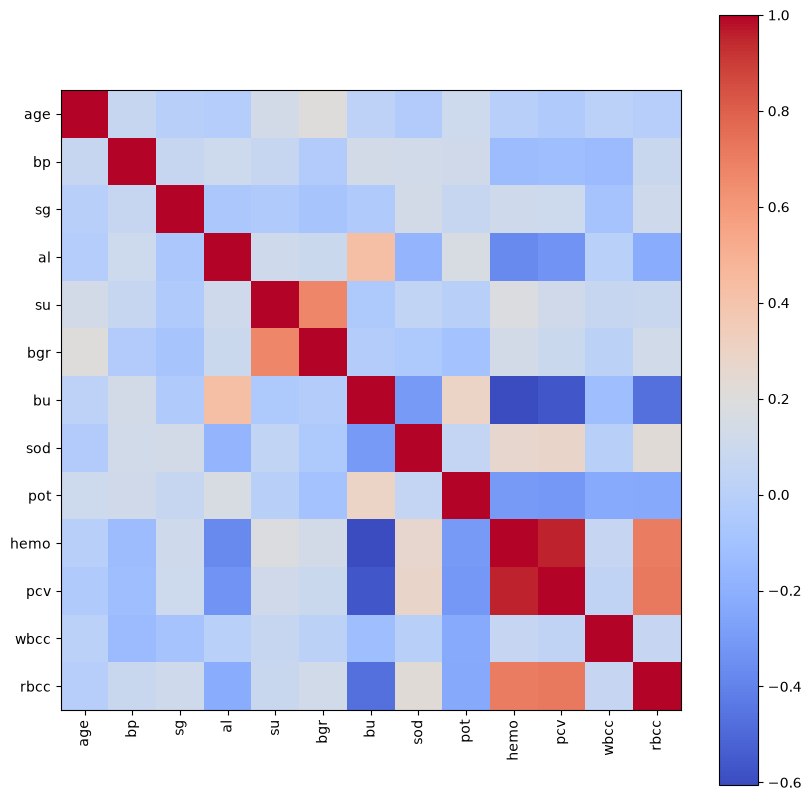

In [29]:
plt.figure(figsize=(10, 10))
plt.imshow(corr_affected, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_affected)), corr_affected.columns, rotation=90)
plt.yticks(range(len(corr_affected)), corr_affected.columns)
plt.show()

In [ ]:
corr_control

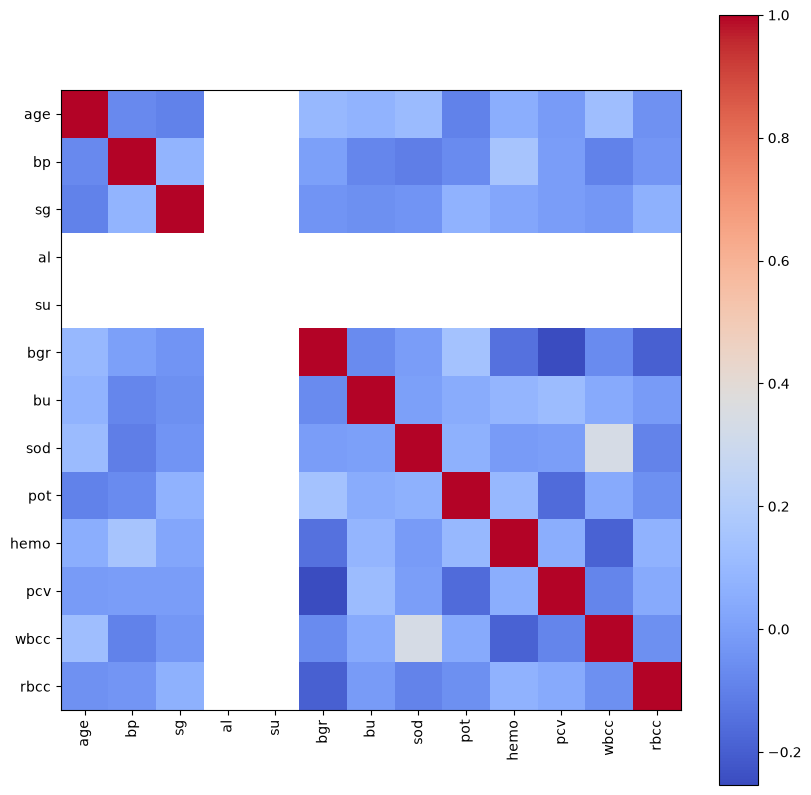

In [27]:
plt.figure(figsize=(10, 10))
plt.imshow(corr_control, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_control)), corr_control.columns, rotation=90)
plt.yticks(range(len(corr_control)), corr_control.columns)
plt.show()

### Data interpretation

- Albumin and sugar in control group in urine was 0 -> NaN -> no variance
- Correlation matrix shows correlation with
    - red blood cell count and hemoglobin
    - packed cell volume and hemoglobin
    - packed cell volume and red blood cell count
    - albumin and bloob urea
        - all above dysfunctional kidneys or chronic inflammation due big molecules such as albumin excreting to the urine
    - blood glugose random and sugar
        - indicates usually for diabetes but dysfunctional kidney might excrete some sugar to the blood